In [1]:
import geopandas as gpd
import pandas as pd

basline_blocks = gpd.read_file('./data/niipg/blocks_agg.geojson')
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,count_supermarket,capacity_park,count_park,capacity_train_building,count_train_building,capacity_kindergarten,count_kindergarten,capacity_school,count_school,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,650.0,1.0,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,0.0,1200.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


# Вычисления **площади участка**

In [2]:
baseline_blocks_test = basline_blocks.copy().to_crs(3857)
basline_blocks["site_area"] = baseline_blocks_test.geometry.area
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,capacity_park,count_park,capacity_train_building,count_train_building,capacity_kindergarten,count_kindergarten,capacity_school,count_school,geometry,site_area
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",836277.821579
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,0.0,0.0,0.0,0.0,0.0,0.0,650.0,1.0,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",420144.041613
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",302985.560228
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,1200.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",124546.982903
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",119574.990985


# Вычисления **связанности**

In [3]:
from blocksnet.analysis.network.accessibility import area_accessibility
matrix = pd.read_pickle('./data/niipg/matrix.pickle')

In [4]:
# переиндексируем матрицу, индекс == столбцы == 0..n-1
matrix = matrix.copy()
matrix.index = range(len(matrix))
matrix.columns = matrix.index

# приводим блоки к тем же меткам
basline_blocks = basline_blocks.reset_index(drop=True)

# проверяем, что размеры совпадают
assert len(matrix) == len(basline_blocks)

area_acc_df = area_accessibility(matrix, basline_blocks)
basline_blocks = basline_blocks.join(area_acc_df)
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,count_park,capacity_train_building,count_train_building,capacity_kindergarten,count_kindergarten,capacity_school,count_school,geometry,site_area,area_accessibility
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",836277.821579,10.063987
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,0.0,0.0,0.0,0.0,0.0,650.0,1.0,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",420144.041613,10.210398
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",302985.560228,8.669212
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",124546.982903,7.467434
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",119574.990985,8.285434


# Вычисления **показателей застройки**

In [5]:
from blocksnet.analysis.indicators import calculate_density_indicators 

blocks_df = calculate_density_indicators(basline_blocks[[
    'site_area',
    'footprint_area',
    'build_floor_area',
    'living_area'
]])
blocks_df.head()

2025-11-28 13:05:57.186 | WARNING  | blocksnet.analysis.indicators.density.schemas:_before_validate:19 - The non_living_area is not in columns, restoring


,site_area,footprint_area,build_floor_area,living_area,non_living_area,fsi,gsi,mxi,l,osr,share_living,share_non_living
0,836277.821579,7383.849525,10126.647386,930.718518,9195.928868,0.012109,0.008829,0.091908,1.371459,81.852753,0.126048,1.245411
1,420144.041613,15304.958732,89136.104333,63508.757346,25627.346987,0.212156,0.036428,0.712492,5.824002,4.541808,4.149554,1.674447
2,302985.560228,17141.628200,91971.715857,72292.449720,19679.266138,0.303551,0.056576,0.786029,5.365401,3.107955,4.217362,1.148039
3,124546.982903,9453.530183,21635.756605,4286.353971,17349.402634,0.173716,0.075903,0.198114,2.288643,5.319595,0.453413,1.835230
4,119574.990985,8567.309559,18736.950831,1791.211457,16945.739375,0.156696,0.071648,0.095598,2.187029,5.924533,0.209075,1.977953


In [6]:
basline_blocks.loc[:, blocks_df.columns] = blocks_df
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,geometry,site_area,area_accessibility,fsi,gsi,mxi,l,osr,share_living,share_non_living
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",836277.821579,10.063987,0.012109,0.008829,0.091908,1.371459,81.852753,0.126048,1.245411
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",420144.041613,10.210398,0.212156,0.036428,0.712492,5.824002,4.541808,4.149554,1.674447
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",302985.560228,8.669212,0.303551,0.056576,0.786029,5.365401,3.107955,4.217362,1.148039
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",124546.982903,7.467434,0.173716,0.075903,0.198114,2.288643,5.319595,0.453413,1.835230
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",119574.990985,8.285434,0.156696,0.071648,0.095598,2.187029,5.924533,0.209075,1.977953


# Вычисления **морфотипов застройки**

In [7]:
from blocksnet.analysis.morphotypes import get_strelka_morphotypes


blocks_df = get_strelka_morphotypes(basline_blocks)
basline_blocks.loc[:, blocks_df.columns] = blocks_df
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,site_area,area_accessibility,fsi,gsi,mxi,l,osr,share_living,share_non_living,morphotype
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,836277.821579,10.063987,0.012109,0.008829,0.091908,1.371459,81.852753,0.126048,1.245411,individual residential
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,420144.041613,10.210398,0.212156,0.036428,0.712492,5.824002,4.541808,4.149554,1.674447,mid-rise
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,302985.560228,8.669212,0.303551,0.056576,0.786029,5.365401,3.107955,4.217362,1.148039,mid-rise
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,124546.982903,7.467434,0.173716,0.075903,0.198114,2.288643,5.319595,0.453413,1.835230,low-rise model
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,119574.990985,8.285434,0.156696,0.071648,0.095598,2.187029,5.924533,0.209075,1.977953,low-rise model


# Выбор **проктной территории**

In [8]:
basline_blocks.columns.to_list()

['residential',
 'business',
 'recreation',
 'industrial',
 'transport',
 'special',
 'agriculture',
 'land_use',
 'share',
 'is_living',
 'number_of_floors',
 'footprint_area',
 'build_floor_area',
 'living_area',
 'non_living_area',
 'population',
 'count',
 'capacity_university',
 'count_university',
 'capacity_guest_house',
 'count_guest_house',
 'capacity_bakery',
 'count_bakery',
 'capacity_houseware',
 'count_houseware',
 'capacity_bus_stop',
 'count_bus_stop',
 'capacity_hospital',
 'count_hospital',
 'capacity_hotel',
 'count_hotel',
 'capacity_fuel',
 'count_fuel',
 'capacity_circus',
 'count_circus',
 'capacity_convenience',
 'count_convenience',
 'capacity_college',
 'count_college',
 'capacity_cafe',
 'count_cafe',
 'capacity_hostel',
 'count_hostel',
 'capacity_bus_station',
 'count_bus_station',
 'capacity_veterinary',
 'count_veterinary',
 'capacity_hairdresser',
 'count_hairdresser',
 'capacity_beach',
 'count_beach',
 'capacity_library',
 'count_library',
 'capacity_b

# Финальный набор данных

In [9]:
cols = [
    'residential','business','recreation','industrial','transport','special',
    'agriculture','land_use','share','footprint_area','build_floor_area',
    'living_area','non_living_area','population','site_area','fsi','gsi',
    'mxi','l','morphotype','area_accessibility', 'geometry'
]
basline_blocks = basline_blocks[cols]
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,non_living_area,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,9195.928868,30.0,836277.821579,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,25627.346987,2000.0,420144.041613,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,19679.266138,2275.0,302985.560228,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,17349.402634,134.0,124546.982903,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,16945.739375,56.0,119574.990985,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


In [10]:
from catboost import CatBoostRegressor

from urbanomy.methods.land_value_modeling import LandPriceEstimator

model = CatBoostRegressor()
model.load_model('./data/catboost_model.cbm')  # модель на лог-цене

estimator = LandPriceEstimator(
    model=model,
    blocks=basline_blocks, #or blocks_198
)
blocks_pred = estimator.predict()
blocks_pred.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,land_value
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,30.0,836277.821579,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",3.049878e+08
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,2000.0,420144.041613,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",5.970137e+08
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,2275.0,302985.560228,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",2.968885e+08
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,134.0,124546.982903,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",9.220754e+07
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,56.0,119574.990985,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",7.750840e+07


count       345.000000
mean      57154.212292
std       34873.696198
min          37.314530
25%       24481.887571
50%       60355.398187
75%       86257.177298
max      125128.468452
Name: price_per_sotka, dtype: float64


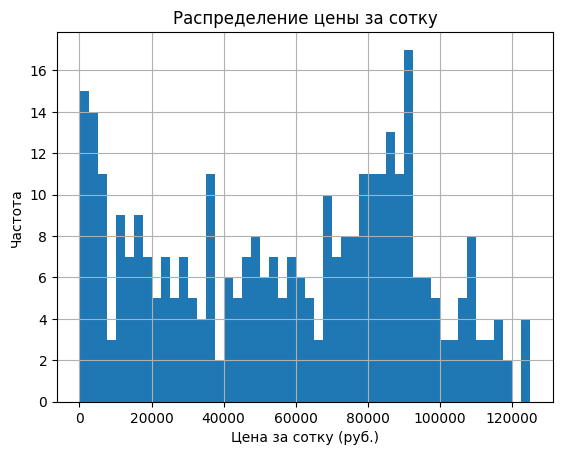

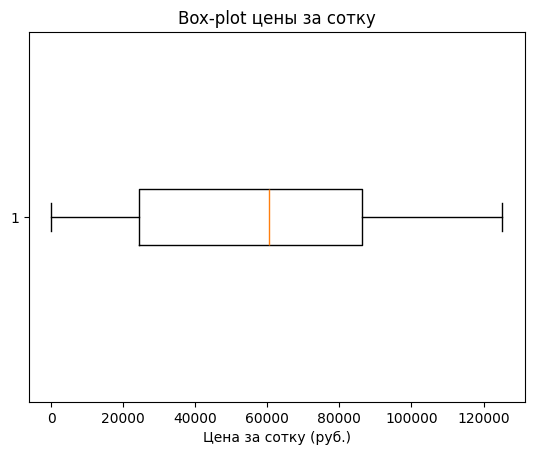

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Цена за сотку (100 м²)
blocks_pred["price_per_sotka"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred["price_per_sotka"] = blocks_pred["price_per_sotka"].replace([np.inf, -np.inf], np.nan)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["price_per_sotka"].quantile(0.99)
blocks_clean = blocks_pred[blocks_pred["price_per_sotka"] <= p99].copy()

print(blocks_clean["price_per_sotka"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["price_per_sotka"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("Распределение цены за сотку")
plt.show()

# 5) Box-plot после очистки
plt.figure()
plt.boxplot(blocks_clean["price_per_sotka"].dropna(), vert=False)
plt.xlabel("Цена за сотку (руб.)")
plt.title("Box-plot цены за сотку")
plt.show()


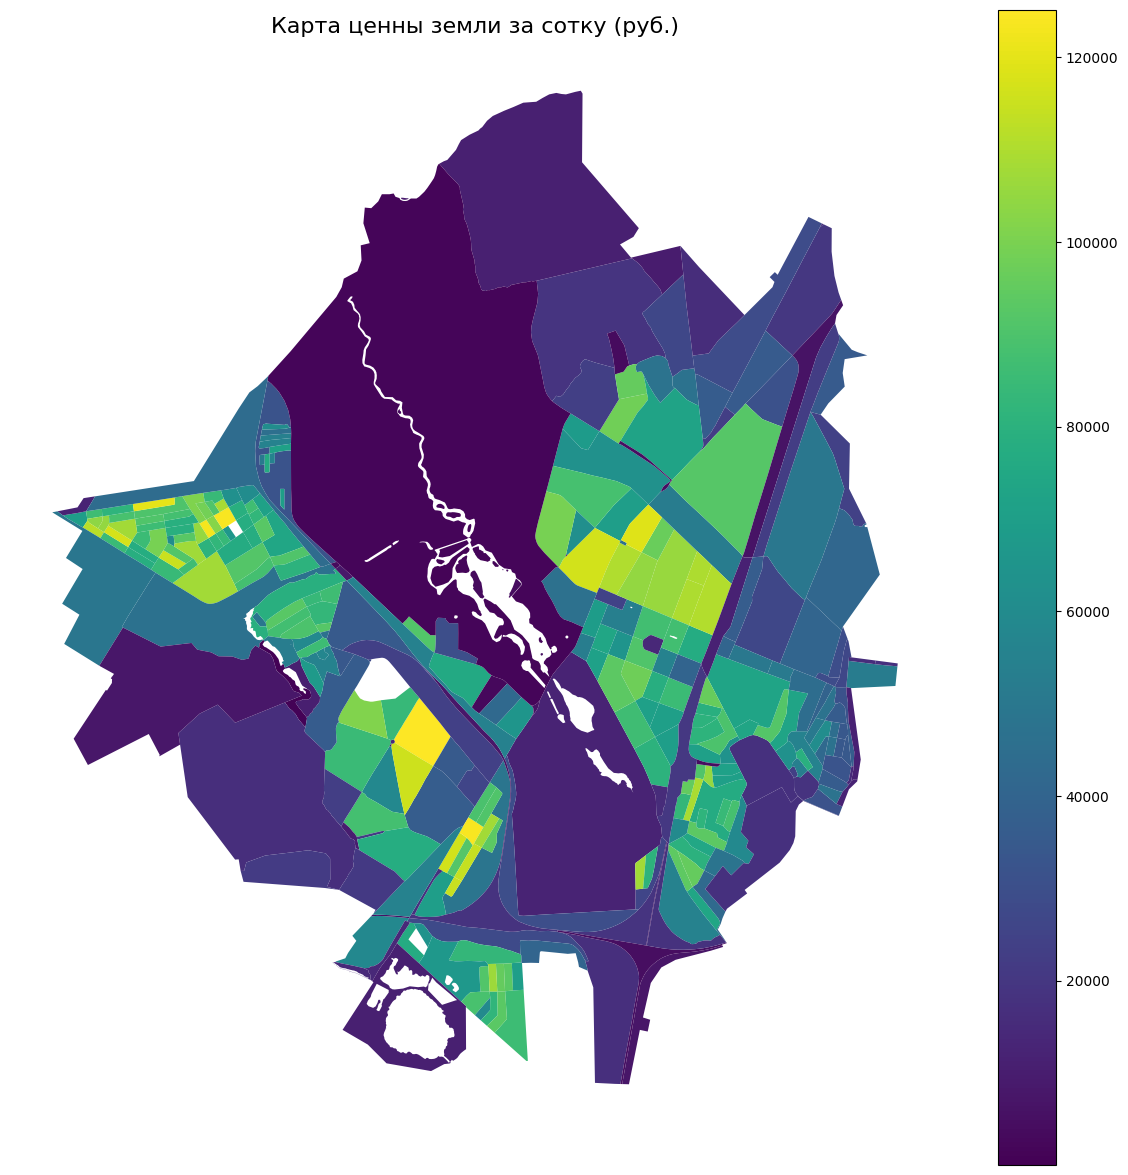

In [12]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='price_per_sotka',
    legend=True,
    figsize=(15,15),
    cmap='viridis'
).set_axis_off()
plt.title('Карта ценны земли за сотку (руб.)', fontsize=16)

plt.show()

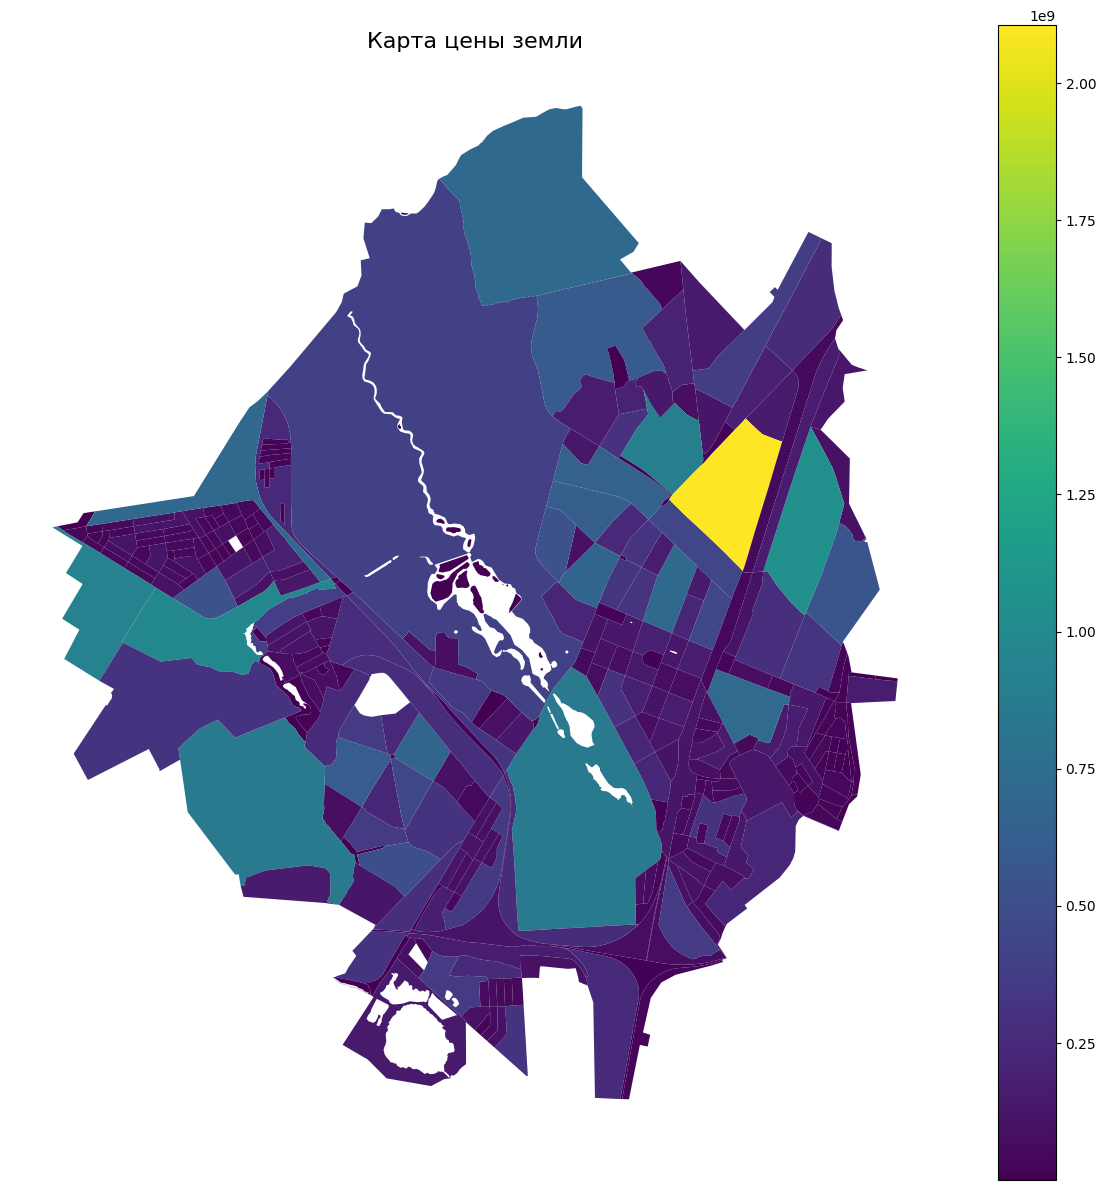

In [13]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(15,15),
    cmap='viridis'
).set_axis_off()
plt.title('Карта цены земли', fontsize=16)

plt.show()

In [14]:
blocks_clean["id"] = blocks_clean.index

In [15]:
blocks_clean.explore()

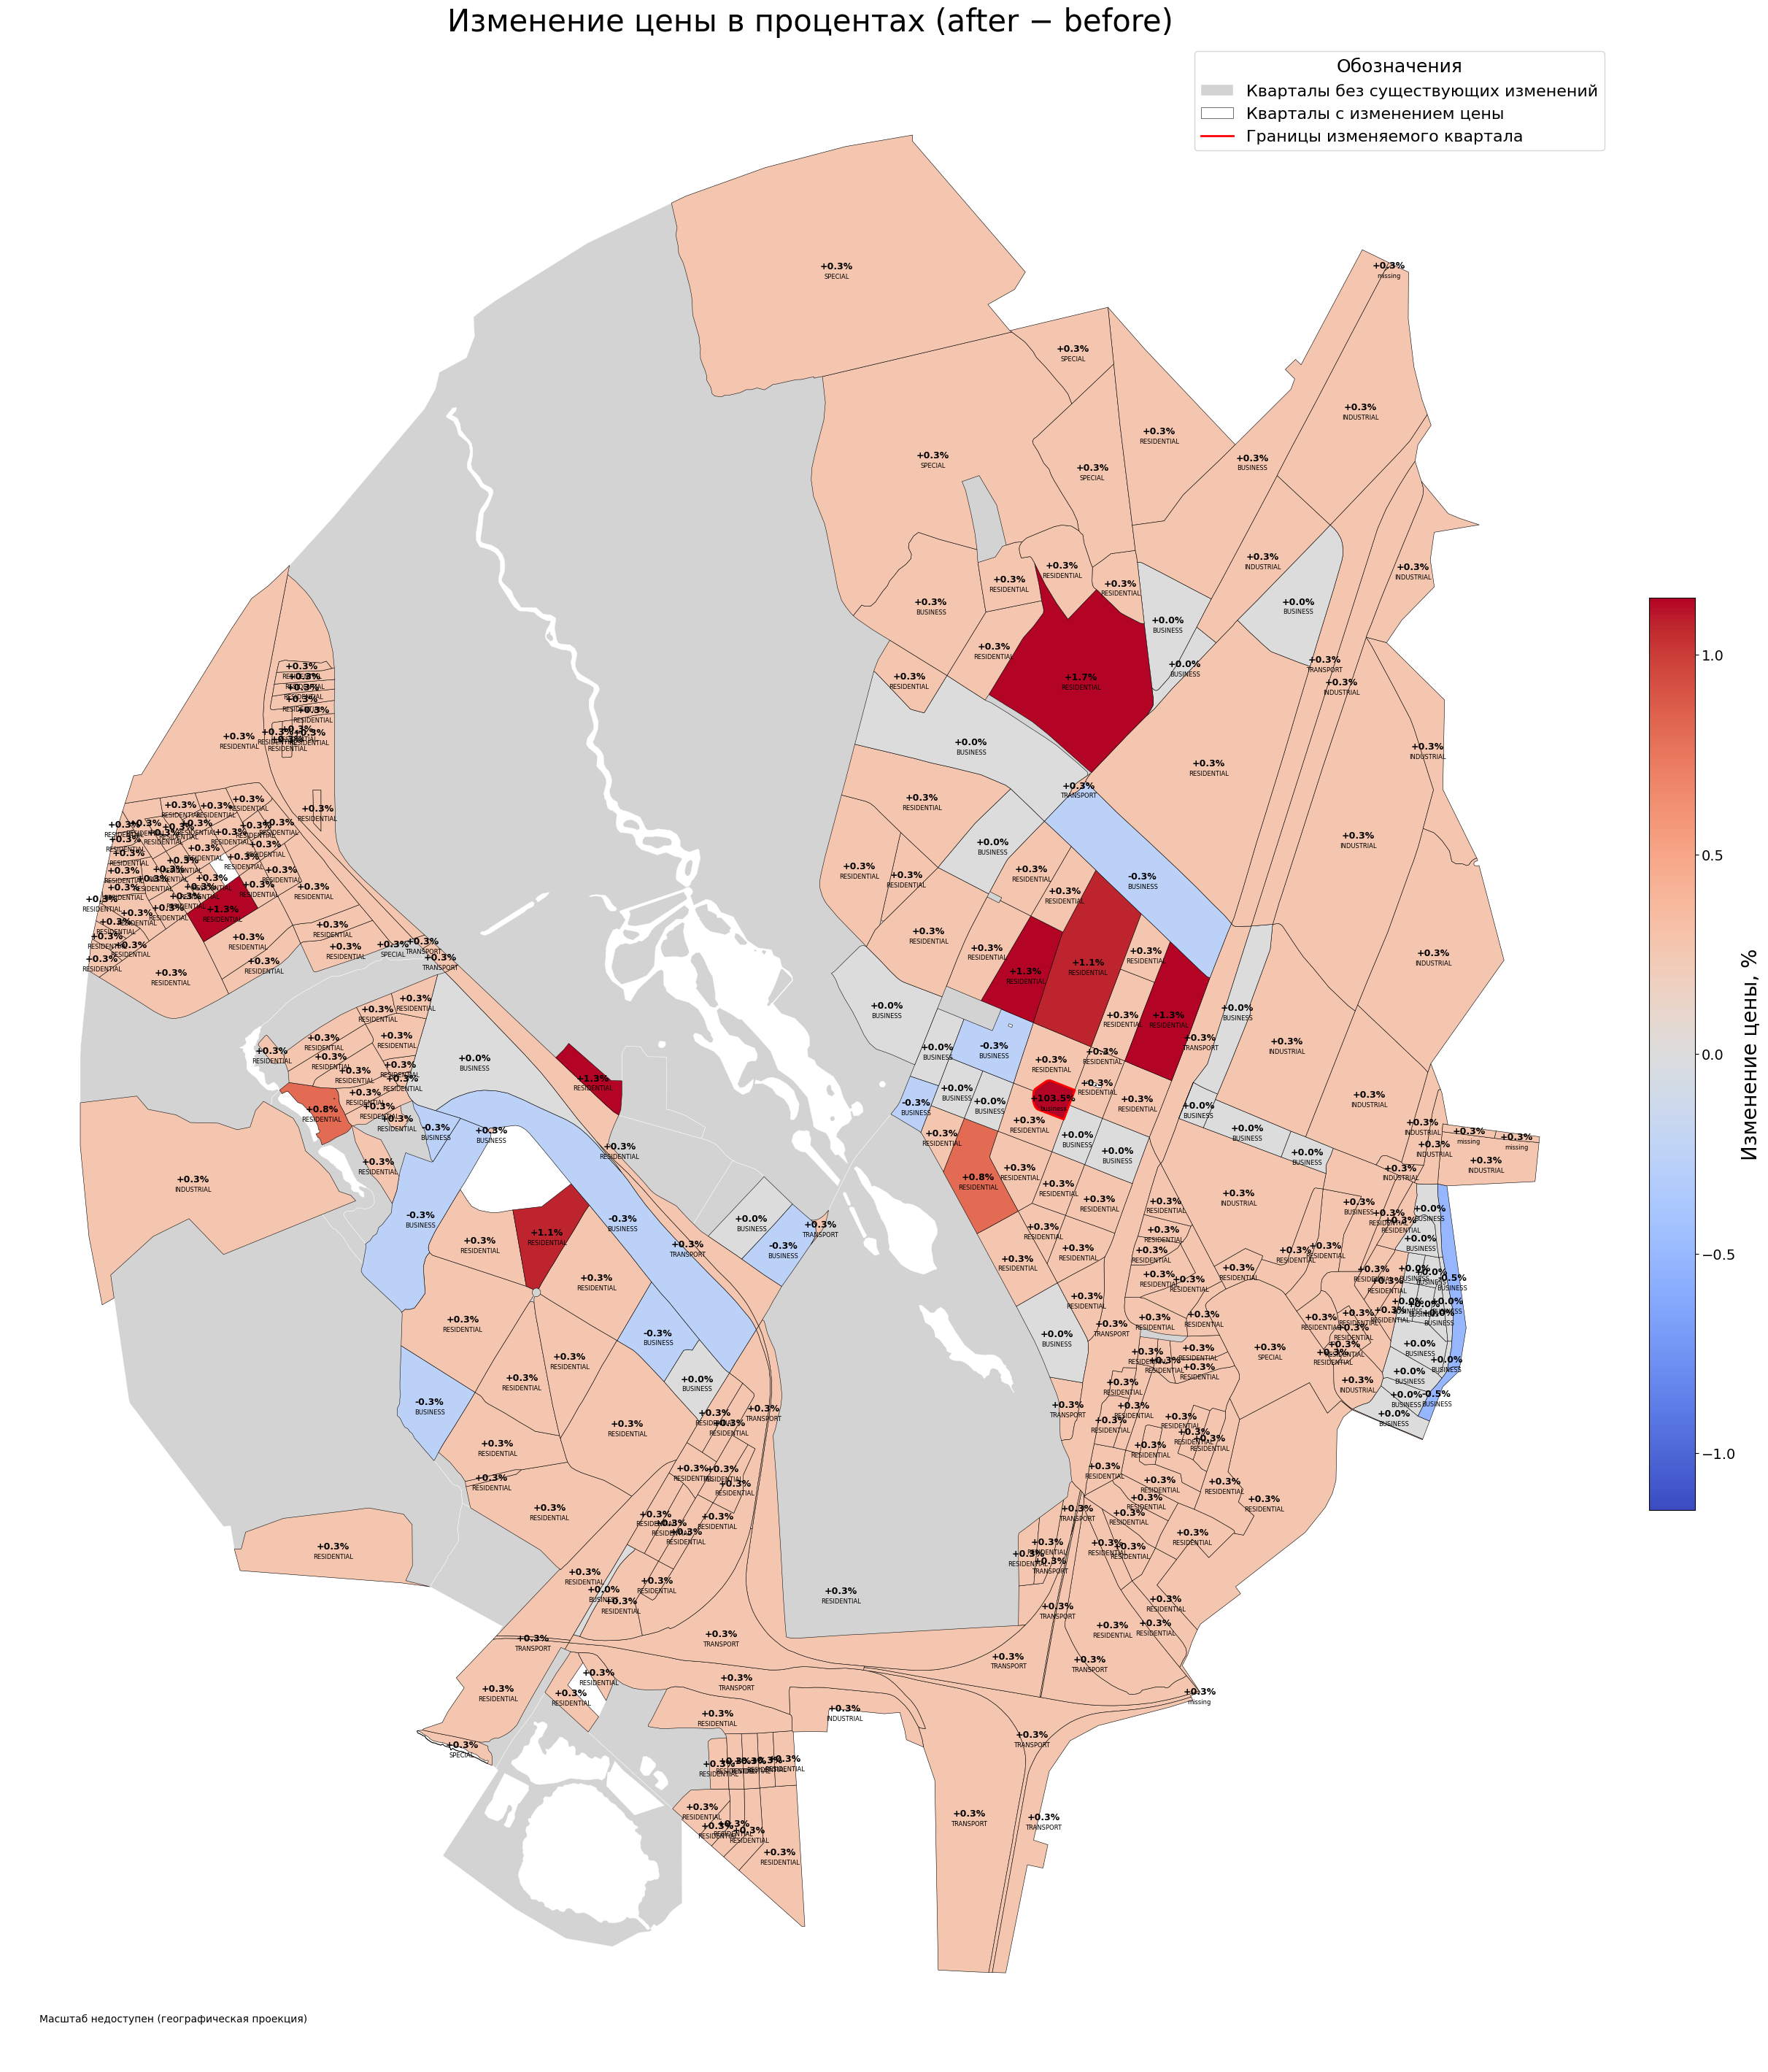


Статистика по кварталам в пределах буфера (|Δ₽| > 1e-09):
index | до (₽) → после (₽) | Δ₽ | Δ%
311 | 295 858 710 ₽ → 296 653 105 ₽ | +794 394 ₽ | +0.3%
248 | 308 723 612 ₽ → 309 552 549 ₽ | +828 937 ₽ | +0.3%
298 | 15 187 471 ₽ → 15 228 250 ₽ | +40 779 ₽ | +0.3%
115 | 52 910 481 ₽ → 53 052 548 ₽ | +142 067 ₽ | +0.3%
317 | 51 382 506 ₽ → 51 520 471 ₽ | +137 964 ₽ | +0.3%
318 | 94 706 652 ₽ → 94 960 944 ₽ | +254 292 ₽ | +0.3%
225 | 68 730 662 ₽ → 68 915 207 ₽ | +184 545 ₽ | +0.3%
299 | 909 871 ₽ → 912 314 ₽ | +2 443 ₽ | +0.3%
5 | 46 149 256 ₽ → 46 273 169 ₽ | +123 913 ₽ | +0.3%
113 | 74 816 927 ₽ → 75 017 814 ₽ | +200 887 ₽ | +0.3%
226 | 34 616 410 ₽ → 34 709 357 ₽ | +92 947 ₽ | +0.3%
180 | 4 ₽ → 4 ₽ | +0 ₽ | +0.3%
117 | 77 450 465 ₽ → 77 658 423 ₽ | +207 958 ₽ | +0.3%
268 | 60 782 422 ₽ → 60 945 626 ₽ | +163 204 ₽ | +0.3%
181 | 360 094 913 ₽ → 361 061 785 ₽ | +966 872 ₽ | +0.3%
341 | 80 158 978 ₽ → 80 374 208 ₽ | +215 231 ₽ | +0.3%
267 | 92 722 713 ₽ → 92 971 678 ₽ | +248 965 ₽ | +0.3%

In [16]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
)

blocks_before = blocks_clean
changes = {
    # Функциональное назначение
    'land_use': 'LandUse.BUSINESS',
    'residential': 0.0,
    'business': 1.0,
    'recreation': 0.0,
    'industrial': 0.0,
    'transport': 0.0,
    'special': 0.0,
    'agriculture': 0.0,
    'share': 1.0,  # участок почти полностью под рекреацию

    # Морфология и площади (при site_area ~303 188 м²)
    'footprint_area': 601,      # небольшие павильоны, спорт-объекты
    'build_floor_area': 601,    # низкая плотность застройки
    'living_area': 0.0,           # жилья нет
    'non_living_area': 601.0,   # вся площадь – нежилая (кафе, спорт, админ.)

    # Население
    'population': 0,              # постоянных жителей нет

    # Морфотип
    'morphotype': 'low-rise non-residential',
}
target_idx = 174

modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_idx, changes)

scenario_result = plot_scenario_impact(
    blocks_before=blocks_before,
    blocks_after=blocks_after,
    model=model,
    target_idx=target_idx,
    figsize=(25, 40),
)

# **Инвестиционная** привлекактельтность 

In [17]:
from blocksnet.enums import LandUse

benchmarks_demo = {
    LandUse.RESIDENTIAL: {
        "cost_build": 45_000,
        "price_sale": 120_000,
        "construction_years": 3,
        "sale_years": 3,
        "opex_rate": 800,
    },
    LandUse.BUSINESS: {
        "cost_build": 55_000,
        "rent_annual": 25_000,
        "rent_years": 12,
        "construction_years": 4,
        "opex_rate": 1_300,
    },
    LandUse.RECREATION: {
        "cost_build": 20_000,
        "rent_annual": 4_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_000,
    },
    LandUse.SPECIAL: {
        "cost_build": 35_000,
        "rent_annual": 11_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_500,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 38_000,
        "rent_annual": 14_800,
        "rent_years": 12,
        "construction_years": 3,
        "opex_rate": 700,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 25_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 300,
    },
    LandUse.TRANSPORT: {
        "cost_build": 18_000,
        "rent_annual": 6_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
    },
}

In [22]:
from urbanomy.methods.investment_potential import prepare_investment_input


potential_df = pd.read_csv("./data/land_use_potentials.csv")

investment_input = prepare_investment_input(
    gdf = blocks_clean,
    project_potential = potential_df,
)

investment_input.head()

2025-11-28 13:07:27.864 | WARNING  | urbanomy.utils.investment_input:_prepare_with_base:347 - prepare_investment_input: у 5 из 345 кварталов нет land-use после нормализации; они остаются в наборе и будут обработаны на следующем этапе.


,land_use,land_value,land_value_before,site_area,living_area,non_living_area,build_floor_area,share,spatial_potential
0,LandUse.RESIDENTIAL,3.049878e+08,3.049878e+08,836277.821579,930.718518,9195.928868,10126.647386,0.690207,0.0
1,LandUse.RESIDENTIAL,2.968885e+08,2.968885e+08,302985.560228,72292.449720,19679.266138,91971.715857,0.936589,0.0
2,LandUse.BUSINESS,9.220754e+07,9.220754e+07,124546.982903,4286.353971,17349.402634,21635.756605,0.819171,2.0
3,LandUse.BUSINESS,7.750840e+07,7.750840e+07,119574.990985,1791.211457,16945.739375,18736.950831,0.931312,2.0
4,LandUse.TRANSPORT,3.784092e+07,3.784092e+07,147123.575644,755.600331,1482.019032,2237.619364,0.737236,4.0


In [23]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_demo)
summary = an.calculate_investment_metrics(investment_input, discount_rate=0.18)
summary

2025-11-28 13:07:32.323 | WARNING  | urbanomy.methods.investment_potential.investment_metrics:calculate_investment_metrics:562 - calculate_investment_metrics: 5 из 345 кварталов без land-use; пропускаем их в расчётах, но оставляем в итоговом отчёте.


Project totals:
 • Land area:          128,896,661.06
 • Built area:         6,140,639.57
 • Land value:         45,877,539,549.81
 • Construction cost:  271,429,902,100.41
 • Investment need:    317,307,441,650.23
 • Spatial potential:  2.40
 • Project NPV:        62,333,218,122.09
 • Project IRR:        0.21
 • Project ROI:        4.71
 • Project PP (yrs):   8.95
 • Project EI:         62.62
 • Project INV score:  61.57


,land_use,land_area,land_value_before,built_area,land_value,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.RESIDENTIAL,836277.82,3.049878e+08,10126.65,3.049878e+08,4.556991e+08,7.606870e+08,-7.483642e+07,0.14,1.94,NaN,0.00,0.0,0.00
1,LandUse.RESIDENTIAL,302985.56,2.968885e+08,91971.72,2.968885e+08,4.138727e+09,4.435616e+09,1.793381e+09,0.34,4.81,4.88,100.00,0.0,58.57
2,LandUse.BUSINESS,124546.98,9.220754e+07,21635.76,9.220754e+07,1.189967e+09,1.282174e+09,1.740323e+08,0.21,10.49,12.12,47.21,2.0,48.37
3,LandUse.BUSINESS,119574.99,7.750840e+07,18736.95,7.750840e+07,1.030532e+09,1.108041e+09,3.063048e+08,0.24,12.44,10.24,69.16,2.0,61.22
4,LandUse.TRANSPORT,147123.58,3.784092e+07,2237.62,3.784092e+07,4.027715e+07,7.811807e+07,-3.979575e+07,0.06,2.08,NaN,0.00,4.0,41.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,LandUse.SPECIAL,751785.26,1.998732e+08,3103.07,1.998732e+08,1.086074e+08,3.084806e+08,-2.002687e+08,0.02,1.30,NaN,0.00,4.0,41.43
341,LandUse.RESIDENTIAL,890764.07,1.423909e+08,NaN,1.423909e+08,NaN,1.423909e+08,2.010228e+10,0.38,5.78,4.73,100.00,0.0,58.57
342,LandUse.RESIDENTIAL,711492.00,1.536543e+08,NaN,1.536543e+08,NaN,1.536543e+08,1.601664e+10,0.37,5.76,4.73,100.00,0.0,58.57
343,LandUse.RESIDENTIAL,568277.77,1.172942e+08,NaN,1.172942e+08,NaN,1.172942e+08,1.279813e+10,0.37,5.76,4.73,100.00,0.0,58.57


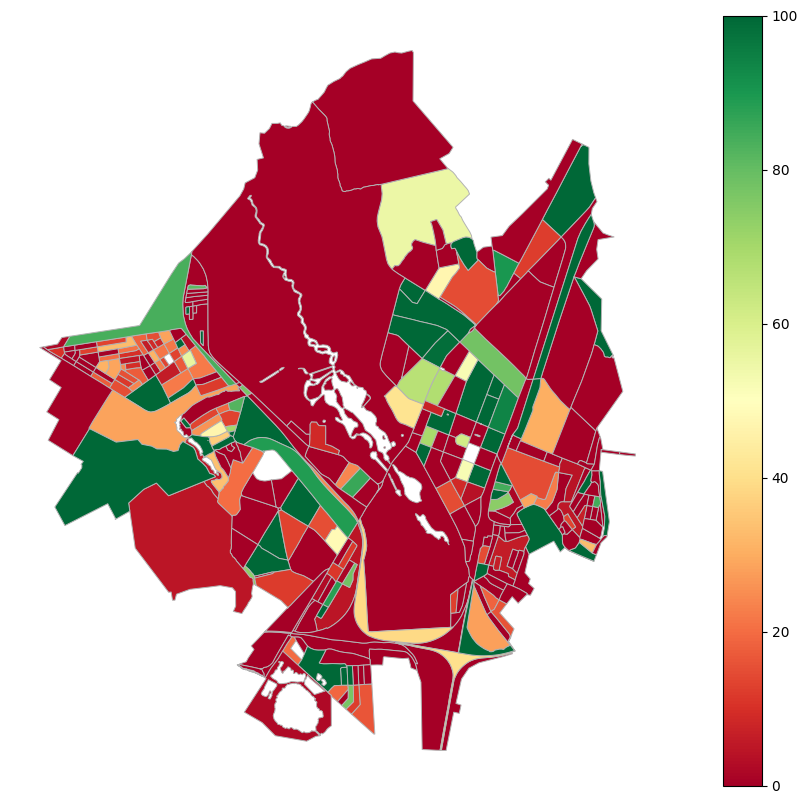

In [ ]:
scn = blocks_clean[['geometry']].join(summary)
column = 'EI'

ax = scn.plot(column=column, cmap='RdYlGn', legend=True, figsize=(15, 10), edgecolor='0.7', linewidth=0.7)
for _, row in scn.dropna(subset=[column]).iterrows():
    x, y = row.geometry.representative_point().coords[0]

ax.set_axis_off()